# 11.14 平均物件線索，還能知道左右順序嗎？


紅條在藍條左邊，交換後紅條在右邊。兩圖的紅藍總量相同，但「紅在藍哪邊」的答案不同。如果入口只平均同一區像素，這項位置線索可能消失。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

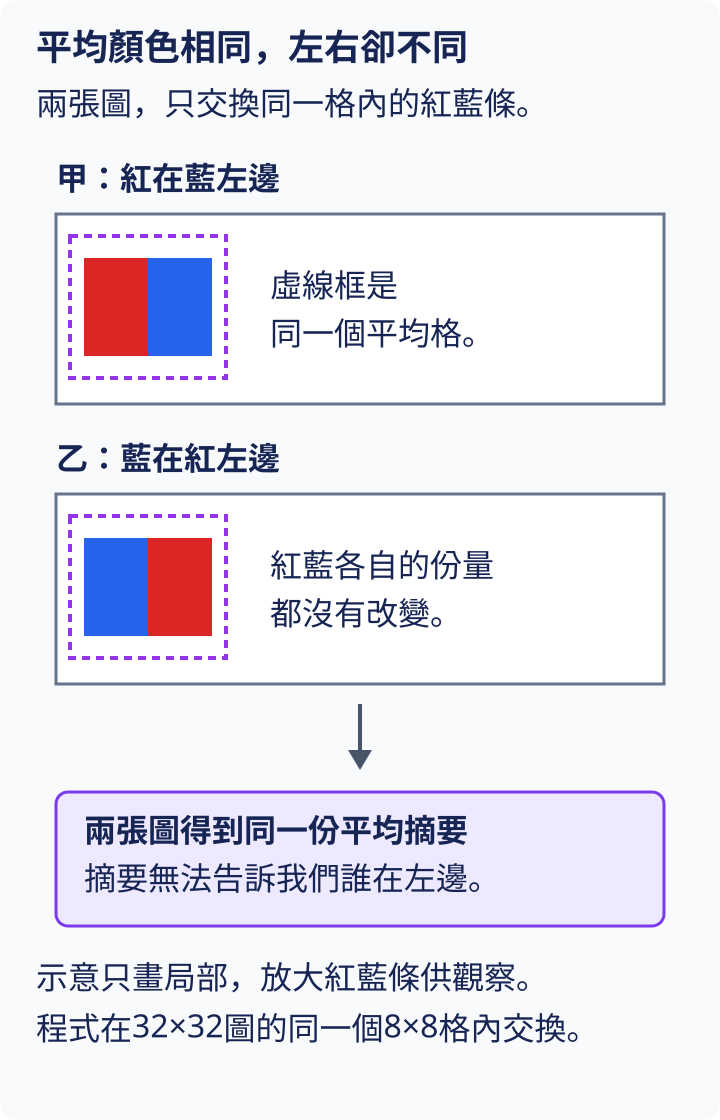

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/practical_order.svg")))

In [3]:
from tiny_perceptron.natural_concepts import picture_order_report

report = picture_order_report()
print("不同的像素數", report["different_pixels"])
print("4乘4平均摘要相同", report["same_4_by_4_summary"])
print("完整像素序列相同", report["same_pixel_sequence"])

不同的像素數 128
4乘4平均摘要相同 True
完整像素序列相同 False


工具建立 32×32 合成圖，只交換同一個 8 像素寬區域內的紅藍順序。印不同數值 128、4×4 平均摘要相同 True、完整序列相同 False。128 分開計 RGB 通道，不是 128 個彩色座標。

每摘要格平均 8×8 像素，這次交換留在同格，所以總和與平均不變。保留完整序列則還能分位置。這是資訊流的反例，沒有載模型，也不證明序列一保留便會懂自然照片。

知道圖有「人、杯子、桌子」也類似，不夠回答誰拿著杯子、杯子在哪邊。關係問答需要相應材料與答案；標物件框是提供位置的一種方法，整圖特徵序列也可以學利用關係。

練習把紅條移到另一個平均格，原格與新格的平均還會一樣嗎？接下來的有限服飾關係圖會用這個問題，明確保留物件與位置，不把物件命名直接當關係理解。

<details>
<summary>回顧與查證</summary>

可回顧：[11.4圖片問答](https://birdhackor.github.io/tiny-perceptron-vlm/11.4.html)、[10.2圖片序列](https://birdhackor.github.io/tiny-perceptron-vlm/10.2.html)。

</details>
